In [40]:
!pip install pandas
!pip install numpy
!pip install backtesting
!pip install backtest

In [41]:
import pandas as pd
import numpy as np
from backtesting import Backtest, Strategy
from backtesting.lib import resample_apply

# df = pd.read_csv(r"C:\Users\vaibh\OneDrive\Desktop\qts\strategies\reliance_fetched_data_1year_15m.csv")
df = pd.read_csv(
    r"C:\Users\vaibh\OneDrive\Desktop\qts\strategies\reliance_fetched_data_1year_15m.csv",
    parse_dates=['datetime'],
    index_col='datetime'
)
# df = df[:200]
df.rename(columns={'open':'Open','high':'High','low':"Low",'close':'Close','volume':'Volume'},inplace=True)

class MomentumStrategy(Strategy):
    small_threshold = 0
    large_threshold = 3
    
    def momentum(self, data):
        return data.pct_change(periods=7).to_numpy() * 100

    def init(self):
        self._pct_change_Long = resample_apply("2h", self.momentum, self.data.Close)
        self.pct_change_Short = resample_apply("30T", self.momentum, self.data.Close)

    def next(self):
        change_long = self._pct_change_Long[-1]
        change_short = self.pct_change_Short[-1]

        if self.position:
            if self.position.is_long and change_short < self.small_threshold:
                self.position.close()
            elif self.position.is_short and change_short > -1 * self.small_threshold:
                self.position.close()
        else:
            if change_long > self.large_threshold and change_short > self.small_threshold:
                self.buy()
            elif change_long < -1 * self.large_threshold and change_short < -1 * self.small_threshold:
                self.sell()

if __name__ == "__main__":
    bt = Backtest(df, MomentumStrategy, cash=10000, commission=0)
    stats = bt.optimize(
        small_threshold=list(np.arange(0, 1.1, 0.2)),
        large_threshold=list(np.arange(4, 5.1, 0.2)),
        max_tries=50,
        maximize="Equity Final [$]"
    )
    print(stats)
    bt.plot()


Start                     2024-10-28 09:15...
End                       2025-05-14 15:15...
Duration                    198 days 06:00:00
Exposure Time [%]                    4.175428
Equity Final [$]                      10451.3
Equity Peak [$]                       10515.7
Return [%]                              4.513
Buy & Hold Return [%]                7.716726
Return (Ann.) [%]                     8.65548
Volatility (Ann.) [%]                 5.00889
Sharpe Ratio                         1.728023
Sortino Ratio                         9.13482
Calmar Ratio                         5.365924
Max. Drawdown [%]                   -1.613046
Avg. Drawdown [%]                   -0.501704
Max. Drawdown Duration       53 days 01:00:00
Avg. Drawdown Duration       17 days 00:11:00
# Trades                                   11
Win Rate [%]                        63.636364
Best Trade [%]                       2.072463
Worst Trade [%]                     -0.459519
Avg. Trade [%]                    

In [42]:
print(f"strategy parameters are {stats._strategy}")
print(f"small threshold : {stats._strategy.small_threshold}")
print(f"long threshold : {stats._strategy.large_threshold}")
print(f"equity_curve is {stats._equity_curve}")

strategy parameters are MomentumStrategy(small_threshold=0.8,large_threshold=4.0)
small threshold : 0.8
long threshold : 4.0
equity_curve is                             Equity  DrawdownPct DrawdownDuration
2024-10-28 09:15:00+05:30  10000.0     0.000000              NaT
2024-10-28 09:30:00+05:30  10000.0     0.000000              NaT
2024-10-28 09:45:00+05:30  10000.0     0.000000              NaT
2024-10-28 10:00:00+05:30  10000.0     0.000000              NaT
2024-10-28 10:15:00+05:30  10000.0     0.000000              NaT
...                            ...          ...              ...
2025-05-14 14:15:00+05:30  10451.3     0.006124              NaT
2025-05-14 14:30:00+05:30  10451.3     0.006124              NaT
2025-05-14 14:45:00+05:30  10451.3     0.006124              NaT
2025-05-14 15:00:00+05:30  10451.3     0.006124              NaT
2025-05-14 15:15:00+05:30  10451.3     0.006124 15 days 02:30:00

[3329 rows x 3 columns]


In [43]:
def walk_forward(
        strategy,
        data_full,
        warmup_bars,
        lookback_bars,
        validation_bars,
        cash=10000000,
        commission=0.002
):
    stats_master = []

    for i in range(lookback_bars, len(data_full)-validation_bars, validation_bars):
        # FIXED HERE: proper slicing
        training_data = data_full.iloc[i - lookback_bars : i]
        validation_data = data_full.iloc[i - warmup_bars : i + validation_bars]

        bt_training = Backtest(training_data, strategy, cash=cash, commission=commission)
        stats_training = bt_training.optimize(
            small_threshold=list(np.arange(0, 1.1, 0.2)),
            large_threshold=list(np.arange(4, 5.1, 0.2)),
            max_tries=50,
            maximize="Sharpe Ratio"
        )
        small_threshold = stats_training._strategy.small_threshold
        large_threshold = stats_training._strategy.large_threshold

        bt_validation = Backtest(validation_data, strategy, cash=cash, commission=commission)
        stats_validation = bt_validation.run(
            small_threshold=small_threshold,
            large_threshold=large_threshold
        )

        stats_master.append(stats_validation)
        # break  # <-- remove break for full walkforward

    return stats_master


In [44]:
lookback_bars = 10
validation_bars = 30
warmup_bars = 10

stats = walk_forward(MomentumStrategy,df,lookback_bars=lookback_bars,validation_bars=validation_bars,warmup_bars=warmup_bars)
print(stats)
# print(stats[0]._strategy)
print(stats[-1])

[Start                     2024-10-28 09:15...
End                       2024-10-29 12:45...
Duration                      1 days 03:30:00
Exposure Time [%]                         0.0
Equity Final [$]                   10000000.0
Equity Peak [$]                    10000000.0
Return [%]                                0.0
Buy & Hold Return [%]                 0.75958
Return (Ann.) [%]                         0.0
Volatility (Ann.) [%]                     NaN
Sharpe Ratio                              NaN
Sortino Ratio                             NaN
Calmar Ratio                              NaN
Max. Drawdown [%]                        -0.0
Avg. Drawdown [%]                         NaN
Max. Drawdown Duration                    NaN
Avg. Drawdown Duration                    NaN
# Trades                                    0
Win Rate [%]                              NaN
Best Trade [%]                            NaN
Worst Trade [%]                           NaN
Avg. Trade [%]                   

In [45]:
def plot_stats(data_slice, stats):
    bt = Backtest(data_slice, MomentumStrategy, cash=1000000, commission=0.002)
    bt.plot(results=stats)

# Reconstruct the same slice of data you used in walk_forward
i = lookback_bars  # (since you only ran one iteration because of 'break')
validation_data = df.iloc[i - warmup_bars : i + validation_bars]

plot_stats(validation_data, stats[0])


In [47]:
!pip install matplotlib

  Using cached matplotlib-3.7.5-cp38-cp38-win_amd64.whl.metadata (5.8 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached kiwisolver-1.4.7-cp38-cp38-win_amd64.whl.metadata (6.4 kB)
  Using cached pyparsing-3.1.4-py3-none-any.whl.metadata (5.1 kB)
  Using cached importlib_resources-6.4.5-py3-none-any.whl.metadata (4.0 kB)
Using cached matplotlib-3.7.5-cp38-cp38-win_amd64.whl (7.5 MB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 7.4 MB/s eta 0:00:00
Using cached importlib_resources-6.4.5-py3-none-any.whl (36 kB)
Using cached kiwisolver-1.4.7-cp38-cp38-win_amd64.whl (55 kB)
Using cached pyparsing-3.1.4-py3-none-any.whl (104 kB)


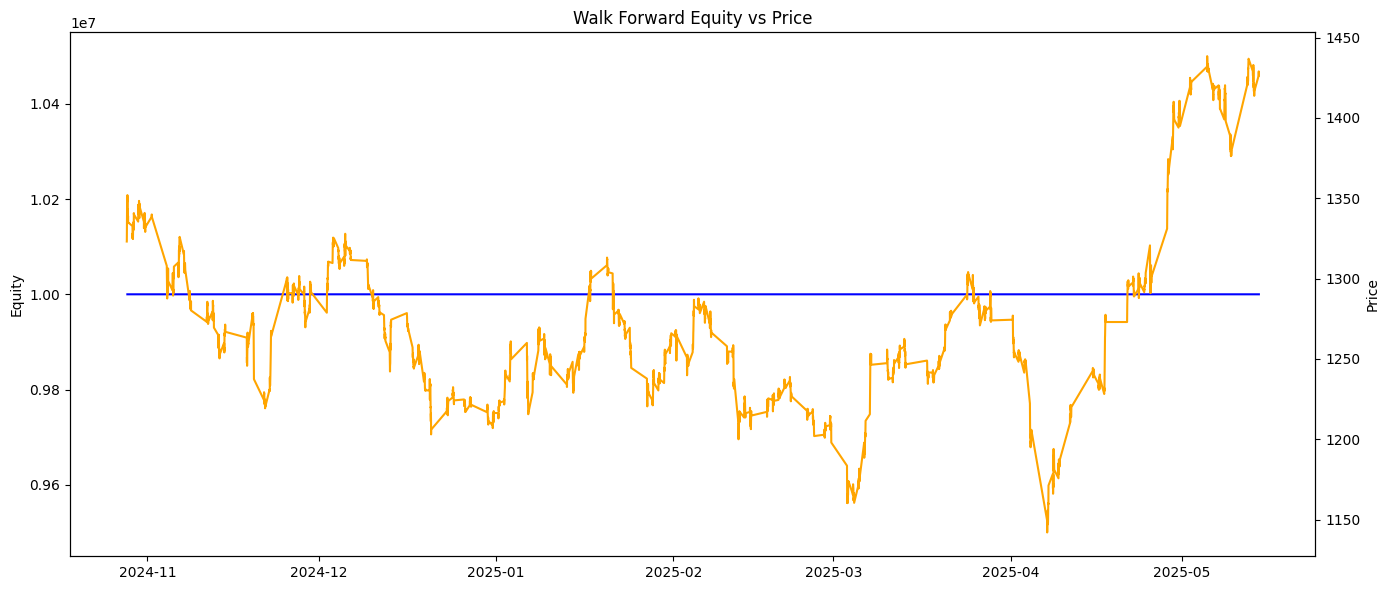

                               Equity  DrawdownPct  DrawdownDuration
2024-10-28 11:45:00+05:30  10000000.0          0.0               NaN
2024-10-28 12:00:00+05:30  10000000.0          0.0               NaN
2024-10-28 12:15:00+05:30  10000000.0          0.0               NaN
2024-10-28 12:30:00+05:30  10000000.0          0.0               NaN
2024-10-28 12:45:00+05:30  10000000.0          0.0               NaN
...                               ...          ...               ...
2025-05-14 09:30:00+05:30  10000000.0          0.0               NaN
2025-05-14 09:45:00+05:30  10000000.0          0.0               NaN
2025-05-14 10:00:00+05:30  10000000.0          0.0               NaN
2025-05-14 10:15:00+05:30  10000000.0          0.0               NaN
2025-05-14 10:30:00+05:30  10000000.0          0.0               NaN

[3300 rows x 3 columns]


In [54]:
import matplotlib.pyplot as plt 

def plot_full_equity_curve(data, stats_list, warmup_bars, lookback_bars):
    equity_curves = [x['_equity_curve'].iloc[warmup_bars:] for x in stats_list]
    combined = pd.concat(equity_curves)
    
    # No iloc needed here
    aligned_price_data = data[data.index <= combined.index[-1]]

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(combined.index, combined.Equity, label="Equity Curve", color="blue")
    ax1.set_ylabel("Equity")
    
    ax2 = ax1.twinx()
    ax2.plot(aligned_price_data.index, aligned_price_data.Close, label="Price", color="orange")
    ax2.set_ylabel("Price")

    plt.title("Walk Forward Equity vs Price")
    fig.tight_layout()
    plt.show()

    print(combined)

plot_full_equity_curve(df,stats,warmup_bars=warmup_bars,lookback_bars=lookback_bars)

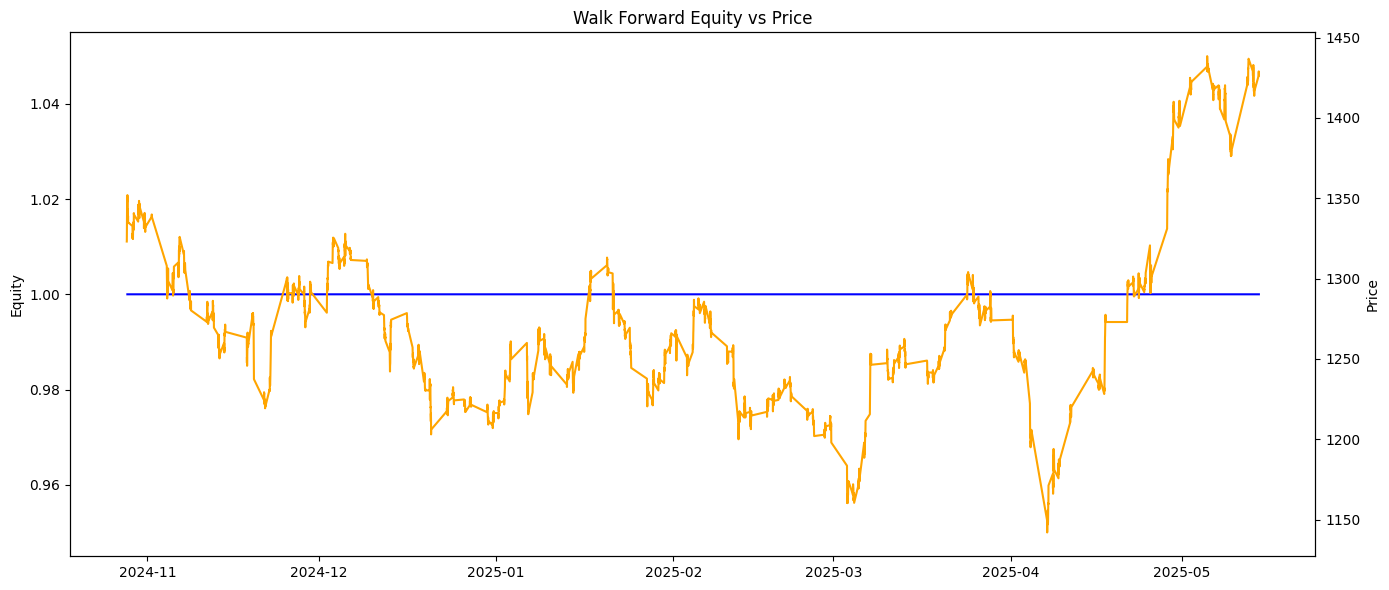

2024-10-28 11:45:00+05:30    1.0
2024-10-28 12:00:00+05:30    1.0
2024-10-28 12:15:00+05:30    1.0
2024-10-28 12:30:00+05:30    1.0
2024-10-28 12:45:00+05:30    1.0
                            ... 
2025-05-14 09:30:00+05:30    1.0
2025-05-14 09:45:00+05:30    1.0
2025-05-14 10:00:00+05:30    1.0
2025-05-14 10:15:00+05:30    1.0
2025-05-14 10:30:00+05:30    1.0
Name: Equity, Length: 3300, dtype: float64


In [53]:
import matplotlib.pyplot as plt

def plot_full_equity_curve(data, stats_list, warmup_bars, lookback_bars):
    equity_curves = [x['_equity_curve'].iloc[warmup_bars:] for x in stats_list]

    # Initialize combined as None first
    combined = None

    for curve in equity_curves:
        equity = curve['Equity'] / 1e7

        if combined is None:
            combined = equity
        else:
            # scale equity relative to last value of combined
            scaled_equity = equity * combined.iloc[-1]
            combined = pd.concat([combined, scaled_equity])
    
    # Now combined.index is datetime always
    aligned_price_data = data[data.index <= combined.index[-1]]

    fig, ax1 = plt.subplots(figsize=(14, 6))
    ax1.plot(combined.index, combined.values, label="Equity Curve", color="blue")
    ax1.set_ylabel("Equity")
    
    ax2 = ax1.twinx()
    ax2.plot(aligned_price_data.index, aligned_price_data.Close, label="Price", color="orange")
    ax2.set_ylabel("Price")

    plt.title("Walk Forward Equity vs Price")
    fig.tight_layout()
    plt.show()

    print(combined)

plot_full_equity_curve(df, stats, warmup_bars=warmup_bars, lookback_bars=lookback_bars)


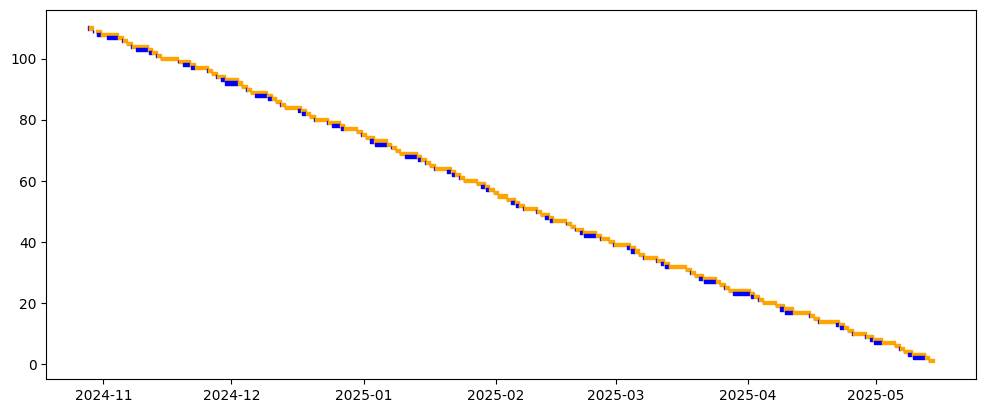

In [58]:
def plot_flow_graph(
        data,
        lookback_bars,
        validation_bars
):
    ranges = list(range(lookback_bars+warmup_bars,len(data)-validation_bars,validation_bars))

    fig,ax = plt.subplots()
    fig.set_figwidth(12)

    for i in range(len(ranges)):
        training_data = data.iloc[ranges[i]-lookback_bars:ranges[i]]
        validation_data = data.iloc[ranges[i]:ranges[i]+validation_bars]
        plt.fill_between(training_data.index,
                         [len(ranges)-i-0.5]*len(training_data.index),
                         [len(ranges)-i+0.5]*len(training_data.index),
                         color="blue"
                         )
        plt.fill_between(validation_data.index,
                         [len(ranges)-i-0.5]*len(validation_data.index),
                         [len(ranges)-i+0.5]*len(validation_data.index),
                         color="orange"
                         )
    plt.show()

plot_flow_graph(df,lookback_bars=lookback_bars,validation_bars=validation_bars)
